# 07. Doubly Robust Estimation

The previous notebooks studied regression adjustment, propensity scores, matching, weighting, balance, and overlap. Each method gave us a different way to build a fair comparison from observational data.

This notebook introduces **doubly robust estimation**, especially the augmented inverse probability weighted estimator, usually abbreviated as AIPW. The idea is elegant:

> Model the outcome and model the treatment assignment. Then combine them so the estimator can remain consistent if either the outcome model or the propensity model is correctly specified.

Doubly robust estimation sounds powerful because it is powerful, but it still requires causal assumptions, overlap, and at least one useful nuisance model. There are two routes to consistency under the usual causal assumptions: one through the outcome model and one through the propensity model.

For industry work, this is a powerful pattern. We often have strong predictive models for outcomes and strong models for targeting decisions. AIPW gives us a disciplined way to combine both while still diagnosing when the design is weak.

## Learning Goals

By the end of this notebook, you should be able to:

1. Define the outcome regression, propensity score, IPW, and AIPW estimators for the ATE.
2. Explain the double robustness property in practical language.
3. Show with code that AIPW behaves well when either nuisance model is correct.
4. Diagnose when AIPW can still be unstable because of poor overlap or extreme weights.
5. Use the AIPW influence-function values to compute a simple uncertainty interval.
6. Explain why cross-fitting is useful when flexible machine learning models estimate the nuisance functions.
7. Write a business-facing readout that does not oversell double robustness.

In [1]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
from pathlib import Path
import sys


def _find_project_root(start=Path.cwd()):
    """
    Locate the portfolio project root so shared notebook utilities can be imported.
    
    Idea:
        The notebooks may be executed from different working directories, so this helper walks upward until it finds the repository structure used by the lecture series.
    
    Args:
        start: Directory where the upward search for the project root begins.
    
    Returns:
        pathlib.Path: Absolute path to the portfolio project root.
    """

    for candidate in [start, *start.parents]:
        if (candidate / "notebooks" / "_shared").exists():
            return candidate
    return start


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm
from scipy.special import expit
from sklearn.base import clone
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import KFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from graphviz import Digraph
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 120)
pd.set_option("display.precision", 3)

from notebooks._shared.display import smart_display

In [2]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def make_dag(edges, title=None, node_colors=None, rankdir="LR"):
    """
    Create a styled Graphviz causal or design diagram for the lecture.
    
    Idea:
        The diagram makes assumptions, assignment mechanisms, and diagnostic workflows visible before the code estimates an effect.
    
    Args:
        edges: Directed edges from source node to target node in the causal or design diagram.
        title: Title displayed on the Graphviz or Matplotlib figure.
        node_colors: Optional mapping from node labels to fill colors.
        rankdir: Graphviz layout direction, such as left-to-right or top-to-bottom.
    
    Returns:
        graphviz.Digraph: Renderable diagram object for display in the notebook.
    """
    node_colors = node_colors or {}
    dot = Digraph(format="svg")
    dot.attr(rankdir=rankdir, bgcolor="transparent", pad="0.2")
    dot.attr("graph", labelloc="t", fontsize="18", fontname="DejaVu Sans")
    if title:
        dot.attr(label=title)
    dot.attr(
        "node",
        shape="box",
        style="rounded,filled",
        fontname="DejaVu Sans",
        fontsize="11",
        margin="0.12,0.08",
        color="#334155",
    )
    dot.attr("edge", color="#475569", arrowsize="0.8", fontname="DejaVu Sans", fontsize="10")
    for node in sorted(set([u for u, _ in edges] + [v for _, v in edges])):
        dot.node(node, fillcolor=node_colors.get(node, "#f8fafc"))
    for u, v in edges:
        dot.edge(u, v)
    return dot


def clip_prob(p, eps=1e-3):
    """
    Clip probabilities away from zero and one for stable causal weighting.
    
    Idea:
        Propensity scores at the boundaries create explosive inverse-probability weights, so clipping is used here as a numerical safeguard and diagnostic device.
    
    Args:
        p: Probability or propensity-score vector to stabilize before weighting.
        eps: Minimum distance from zero and one used when clipping probabilities.
    
    Returns:
        numpy.ndarray: Probability vector bounded between eps and one minus eps.
    """
    return np.clip(np.asarray(p, dtype=float), eps, 1 - eps)


def effective_sample_size(weights):
    """Compute Kish effective sample size from a vector of weights.

    Args:
        weights: Observation weights used to define the target pseudo-population or summary.

    Returns:
        float: Effective sample size implied by the design or weights.
    """
    weights = np.asarray(weights, dtype=float)
    return (weights.sum() ** 2) / np.sum(weights ** 2)


def weight_summary(weights):
    """Summarize weight concentration and effective sample size.

    Args:
        weights: Observation weights used to define the target pseudo-population or summary.

    Returns:
        pandas.Series: Weight distribution and effective sample size diagnostics.
    """
    weights = np.asarray(weights, dtype=float)
    return {
        "ess": effective_sample_size(weights),
        "ess_share_of_n": effective_sample_size(weights) / len(weights),
        "mean": weights.mean(),
        "sd": weights.std(),
        "p95": np.quantile(weights, 0.95),
        "p99": np.quantile(weights, 0.99),
        "max": weights.max(),
    }


def weighted_mean(x, w):
    """Compute a weighted average while handling the lecture’s vector format.

    Args:
        x: Numeric vector or covariate values used in the calculation.
        w: Weight vector used for weighted summaries.

    Returns:
        float: Weighted average.
    """
    x = np.asarray(x, dtype=float)
    w = np.asarray(w, dtype=float)
    return np.sum(w * x) / np.sum(w)


def standardized_mean_difference(x, d, weights=None):
    """Compute an absolute standardized mean difference for covariate balance.

    Args:
        x: Numeric vector or covariate values used in the calculation.
        d: Treatment indicator used in weighting, balance, or effect estimation.
        weights: Observation weights used to define the target pseudo-population or summary.

    Returns:
        float: Numeric diagnostic or estimate used by the lecture.
    """
    x = np.asarray(x, dtype=float)
    d = np.asarray(d, dtype=int) == 1
    if weights is None:
        weights = np.ones(len(x))
    weights = np.asarray(weights, dtype=float)
    mt = weighted_mean(x[d], weights[d])
    mc = weighted_mean(x[~d], weights[~d])
    vt = weighted_mean((x[d] - mt) ** 2, weights[d])
    vc = weighted_mean((x[~d] - mc) ** 2, weights[~d])
    pooled = np.sqrt((vt + vc) / 2)
    return np.nan if pooled == 0 else (mt - mc) / pooled


def balance_table(frame, covariates, weights=None):
    """
    Summarize covariate balance between treatment groups or weighted pseudo-populations.
    
    Idea:
        Balance tables check whether an experiment or adjustment strategy made treated and comparison units look similar on pre-treatment variables.
    
    Args:
        frame: Analysis DataFrame containing the treatment, outcome, score, or covariate columns used by the helper.
        covariates: Pre-treatment covariate columns evaluated for balance or adjustment.
        weights: Optional observation weights defining the adjusted pseudo-population.
    
    Returns:
        pandas.DataFrame: Covariate means, differences, and standardized balance diagnostics.
    """
    rows = []
    for covariate in covariates:
        smd = standardized_mean_difference(frame[covariate], frame["treated"], weights=weights)
        rows.append({"covariate": covariate, "smd": smd, "abs_smd": abs(smd)})
    return pd.DataFrame(rows).sort_values("abs_smd", ascending=False)


def plot_love(balance_tables, title, threshold=0.10, figsize=None):
    """Create a Love plot comparing covariate imbalance across designs.

    Args:
        balance_tables: Collection of balance tables to compare across designs.
        title: Title shown on the resulting figure.
        threshold: Diagnostic threshold used to flag imbalance.
        figsize: Matplotlib figure size.

    Returns:
        tuple: Matplotlib figure and axes for the balance plot.
    """
    plot_df = pd.concat(
        [table.assign(design=label) for label, table in balance_tables.items()],
        ignore_index=True,
    )
    order = plot_df.groupby("covariate")["abs_smd"].max().sort_values(ascending=True).index
    if figsize is None:
        figsize = (9, max(4.5, 0.38 * len(order)))
    fig, ax = plt.subplots(figsize=figsize)
    sns.scatterplot(data=plot_df, x="smd", y="covariate", hue="design", style="design", s=80, ax=ax, zorder=3)
    ax.axvline(0, color="#64748b", linewidth=1)
    ax.axvline(threshold, color="#94a3b8", linestyle="--", linewidth=1)
    ax.axvline(-threshold, color="#94a3b8", linestyle="--", linewidth=1)
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels(order)
    ax.set_xlabel("Standardized mean difference")
    ax.set_ylabel("")
    ax.set_title(title)
    ax.legend(frameon=False, loc="lower right")
    sns.despine(ax=ax)
    plt.show()

## 1. The Two Single-Robust Routes

Under no unmeasured confounding and positivity, the ATE can be estimated in two familiar ways.

The **outcome regression route** models the conditional mean outcome under each treatment level:

$$
m_d(X_i) = E[Y_i \mid D_i=d, X_i], \quad d \in \{0,1\}.
$$

Then it estimates:

$$
\widehat{ATE}_{OR} = \frac{1}{n}\sum_{i=1}^{n}\{\hat m_1(X_i) - \hat m_0(X_i)\}.
$$

The **propensity weighting route** models the treatment probability:

$$
e(X_i) = P(D_i=1 \mid X_i).
$$

Then it uses inverse probability weights to reweight observed outcomes:

$$
\widehat{ATE}_{IPW} = \frac{1}{n}\sum_{i=1}^{n}\left\{\frac{D_iY_i}{\hat e(X_i)} - \frac{(1-D_i)Y_i}{1-\hat e(X_i)}\right\}.
$$

Each route is single-robust. Outcome regression relies on a correct enough outcome model. IPW relies on a correct enough propensity model and good overlap.

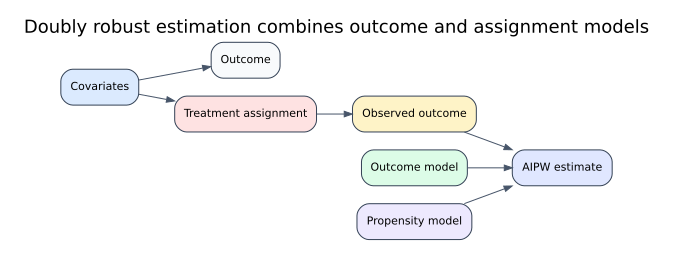

In [3]:
# Organize the calculation into readable steps for the lecture narrative.
dr_edges = [
    ("Covariates", "Treatment assignment"),
    ("Covariates", "Outcome"),
    ("Treatment assignment", "Observed outcome"),
    ("Outcome model", "AIPW estimate"),
    ("Propensity model", "AIPW estimate"),
    ("Observed outcome", "AIPW estimate"),
]

make_dag(
    dr_edges,
    title="Doubly robust estimation combines outcome and assignment models",
    node_colors={
        "Covariates": "#dbeafe",
        "Treatment assignment": "#fee2e2",
        "Outcome": "#f8fafc",
        "Observed outcome": "#fef3c7",
        "Outcome model": "#dcfce7",
        "Propensity model": "#ede9fe",
        "AIPW estimate": "#e0e7ff",
    },
)

The two nuisance functions have different jobs:

- $\hat m_1(X)$ and $\hat m_0(X)$ predict the missing potential outcome means.
- $\hat e(X)$ tells us how surprising each observed treatment assignment was.

AIPW combines both. The outcome model gives a baseline estimate of each unit's treatment contrast. The propensity model controls how much we trust residual information from observed treated and untreated outcomes.

## 2. The AIPW Estimator

The AIPW estimator for the ATE can be written as:

$$
\widehat{ATE}_{AIPW}
= \frac{1}{n}\sum_{i=1}^{n}
\left[
\hat m_1(X_i) - \hat m_0(X_i)
+ \frac{D_i\{Y_i - \hat m_1(X_i)\}}{\hat e(X_i)}
- \frac{(1-D_i)\{Y_i - \hat m_0(X_i)\}}{1-\hat e(X_i)}
\right].
$$

Read it as:

$$
\text{AIPW} = \text{outcome-model contrast} + \text{weighted residual correction}.
$$

If the outcome model is right, the residual corrections average to zero. If the propensity model is right, the residual corrections repair the outcome model's misspecification. This is the double robustness property discussed in the missing-data and causal-inference literature by Robins, Rotnitzky, and Zhao (1994) and Bang and Robins (2005). Funk et al. (2011) give an accessible causal-effects presentation of this idea.

## 3. Running Example: Renewal Outreach With Two Modeling Routes

We will simulate the same kind of setting as before: a SaaS company evaluates proactive renewal outreach.

The company targets outreach using churn risk, segment, contract value, engagement, and support capacity. Renewal outcomes depend on overlapping but not identical drivers. This gives us a realistic nuisance-function problem:

- Some variables predict treatment strongly.
- Some variables predict outcome strongly.
- Some variables do both and are true confounders.
- One variable, support capacity, affects treatment but not the outcome directly.

**Dataset and experiment setup.** The AIPW example represents renewal outreach in an observational customer population. The data include pre-treatment predictors of assignment and outcome, a treatment indicator, and a post-period outcome. Two nuisance models matter: the propensity model for treatment assignment and the outcome model for expected outcomes. The simulation deliberately allows one model to be right while the other is wrong so the notebook can demonstrate double robustness. This is closer to applied work than a perfectly specified example, because real teams rarely know which nuisance model is safest.

In [4]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def simulate_renewal_outreach(n=7000, seed=7070, targeting_strength=1.0):
    """
    Generate renewal-outreach observational data with controllable targeting strength.
    
    Idea:
        The simulation creates known confounding so doubly robust estimators can be compared against a teaching truth.
    
    Args:
        n: Number of observations to simulate or draw.
        seed: Random seed for reproducible simulation or bootstrap draws.
        targeting_strength: Strength of confounded treatment targeting in the simulated outreach data.
    
    Returns:
        pandas.DataFrame: Simulated customer records with covariates, treatment, observed outcome, and known potential-outcome structure.
    """
    rng = np.random.default_rng(seed)

    segment = rng.choice(["starter", "growth", "enterprise"], p=[0.42, 0.38, 0.20], size=n)
    segment_score = pd.Series(segment).map({"starter": 0.0, "growth": 1.0, "enterprise": 2.0}).to_numpy()

    tenure = np.clip(rng.gamma(shape=2.3, scale=7.5, size=n), 1, 60)
    engagement = np.clip(rng.normal(42 + 4 * segment_score + 0.35 * tenure, 13, n), 2, 100)
    contract_value = np.clip(
        rng.lognormal(3.7 + 0.25 * segment_score + 0.006 * engagement, 0.55, n),
        20,
        600,
    )
    support_capacity = rng.normal(0, 1, n)

    risk_score = expit(
        1.2
        - 0.045 * engagement
        - 0.004 * contract_value
        + 0.012 * tenure
        - 0.45 * segment_score
        + rng.normal(0, 0.8, n)
    )

    base_assignment = (
        2.4 * risk_score
        + 0.55 * (segment == "enterprise")
        + 0.25 * (segment == "growth")
        + 0.004 * contract_value
        - 0.018 * engagement
        + 0.75 * support_capacity
        + 1.15 * risk_score * (segment == "enterprise")
    )
    true_propensity = expit(-0.85 + targeting_strength * base_assignment)
    treated = rng.binomial(1, true_propensity)

    outcome_without_treatment = (
        52
        + 0.16 * engagement
        + 0.035 * contract_value
        + 0.09 * tenure
        + 2.4 * segment_score
        - 14.0 * risk_score
        + 5.0 * risk_score**2
        + 2.7 * np.sin(engagement / 18)
        + 2.0 * risk_score * (segment == "enterprise")
        + rng.normal(0, 4.5, n)
    )

    treatment_effect = (
        2.1
        + 0.55 * (segment == "growth")
        + 1.10 * (segment == "enterprise")
        + 0.010 * engagement
        - 1.25 * risk_score
        + 0.0008 * contract_value
    )
    outcome = outcome_without_treatment + treatment_effect * treated

    return pd.DataFrame({
        "segment": segment,
        "tenure": tenure,
        "engagement": engagement,
        "contract_value": contract_value,
        "support_capacity": support_capacity,
        "risk_score": risk_score,
        "true_propensity": true_propensity,
        "treated": treated,
        "outcome": outcome,
        "outcome_without_treatment": outcome_without_treatment,
        "true_individual_effect": treatment_effect,
    })


df = simulate_renewal_outreach()
true_ate = df["true_individual_effect"].mean()
naive_effect = df.loc[df["treated"] == 1, "outcome"].mean() - df.loc[df["treated"] == 0, "outcome"].mean()

summary = pd.DataFrame({
    "quantity": [
        "Number of accounts",
        "Share receiving outreach",
        "True ATE in simulation",
        "Naive treated-control difference",
        "Naive bias vs true ATE",
    ],
    "value": [
        len(df),
        df["treated"].mean(),
        true_ate,
        naive_effect,
        naive_effect - true_ate,
    ],
})

smart_display(summary)
smart_display(df.head())

,quantity,value
0,Number of accounts,7000.000
1,Share receiving outreach,0.355
2,True ATE in simulation,2.825
3,Naive treated-control difference,2.011
4,Naive bias vs true ATE,-0.814


,segment,tenure,engagement,contract_value,support_capacity,risk_score,true_propensity,treated,outcome,outcome_without_treatment,true_individual_effect
0,starter,15.498,52.335,35.095,-2.492,0.174,0.043,0,69.203,69.203,2.433
1,growth,9.371,47.239,44.833,-0.268,0.190,0.266,0,68.120,68.120,2.921
2,growth,11.209,32.476,44.873,-0.479,0.364,0.380,0,55.890,55.890,2.555
3,enterprise,6.854,54.315,84.787,0.147,0.037,0.333,0,62.898,62.898,3.765
4,growth,5.026,46.038,101.334,1.385,0.175,0.607,1,59.087,56.114,2.973


The naive comparison is biased because outreach is targeted. The true ATE is known only because this is a simulation. In real data, we would not know it; we would rely on design assumptions, diagnostics, and sensitivity checks.

This example is intentionally moderate on overlap. We want the doubly robust property to be visible without letting extreme weights dominate the entire story. Later we will stress-test AIPW under weaker overlap.

## 4. Inspect Treatment Assignment and Confounding

Before estimating anything, look at the treatment process. If the treatment is strongly predictable from covariates, then both weighting and AIPW will need careful overlap diagnostics.

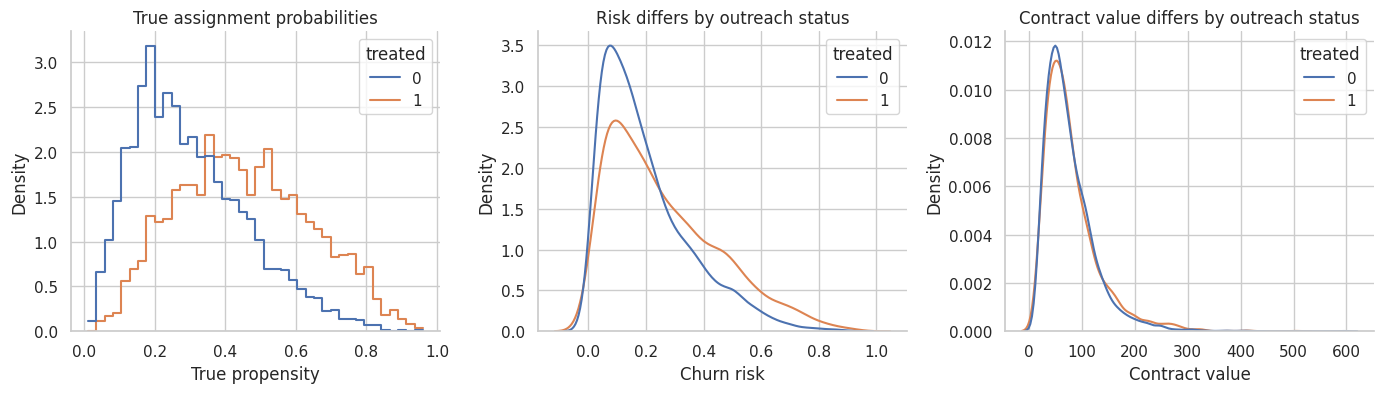

In [5]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
fig, axes = plt.subplots(1, 3, figsize=(14, 4.1))

sns.histplot(data=df, x="true_propensity", hue="treated", bins=40, stat="density", common_norm=False, element="step", fill=False, ax=axes[0])
axes[0].set_title("True assignment probabilities")
axes[0].set_xlabel("True propensity")

sns.kdeplot(data=df, x="risk_score", hue="treated", common_norm=False, fill=False, ax=axes[1])
axes[1].set_title("Risk differs by outreach status")
axes[1].set_xlabel("Churn risk")

sns.kdeplot(data=df, x="contract_value", hue="treated", common_norm=False, fill=False, ax=axes[2])
axes[2].set_title("Contract value differs by outreach status")
axes[2].set_xlabel("Contract value")

for ax in axes:
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()

In Inspect Treatment Assignment and Confounding, the figure shows whether the comparison is supported by nearby observed units or by extrapolation. Weak overlap narrows the population we can speak about.

In [6]:
# Assemble the Inspect Treatment Assignment and Confounding summary table used for interpretation.
segment_dummies = pd.get_dummies(df["segment"], prefix="segment", dtype=float)
balance_frame = pd.concat(
    [df[["treated", "risk_score", "engagement", "contract_value", "tenure", "support_capacity"]], segment_dummies],
    axis=1,
)
balance_covariates = [c for c in balance_frame.columns if c != "treated"]

raw_balance = balance_table(balance_frame, balance_covariates)
smart_display(raw_balance)

,covariate,smd,abs_smd
4,support_capacity,0.675,0.675
0,risk_score,0.362,0.362
1,engagement,-0.340,0.340
3,tenure,-0.070,0.070
2,contract_value,0.069,0.069
5,segment_enterprise,0.066,0.066
6,segment_growth,-0.033,0.033
7,segment_starter,-0.020,0.020


The raw groups are not comparable. Churn risk, contract value, engagement, and segment mix differ between treated and untreated accounts. Any credible observational estimate has to address this imbalance.

Doubly robust estimation does not remove the need for these checks. It simply gives us a way to combine two adjustment strategies.

## 5. Fit Correct and Incorrect Nuisance Models

To make double robustness visible, we will deliberately create two propensity models and two outcome models.

The **richer** models include the key nonlinearities and segment terms used in the data-generating process. The **misspecified** models omit important confounders and nonlinear structure.

In a real project, we never know which model is correct. The purpose of this controlled example is pedagogical: it lets us see what AIPW is designed to protect against.

In [7]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
ps_formula_correct = "treated ~ risk_score + I(risk_score ** 2) + engagement + contract_value + tenure + support_capacity + C(segment) + risk_score:C(segment)"
ps_formula_wrong = "treated ~ engagement + tenure"

outcome_formula_correct = "outcome ~ risk_score + I(risk_score ** 2) + engagement + np.sin(engagement / 18) + contract_value + tenure + C(segment) + risk_score:C(segment)"
outcome_formula_wrong = "outcome ~ engagement + tenure"


def fit_propensity_formula(frame, formula):
    """Fit a logistic propensity model from a formula.

    Args:
        frame: Analysis DataFrame to copy, transform, or summarize.
        formula: Statsmodels formula describing the model specification.

    Returns:
        statsmodels result: Fitted logistic propensity model.
    """
    model = smf.glm(formula, data=frame, family=sm.families.Binomial()).fit(maxiter=100)
    return clip_prob(model.predict(frame)), model


def fit_outcome_formula(frame, formula):
    """Fit separate outcome models for treated and comparison units.

    Args:
        frame: Analysis DataFrame to copy, transform, or summarize.
        formula: Statsmodels formula describing the model specification.

    Returns:
        tuple: Fitted outcome models for untreated and treated units.
    """
    treated_model = smf.ols(formula, data=frame.loc[frame["treated"] == 1]).fit()
    control_model = smf.ols(formula, data=frame.loc[frame["treated"] == 0]).fit()
    m1 = treated_model.predict(frame)
    m0 = control_model.predict(frame)
    return np.asarray(m0), np.asarray(m1), control_model, treated_model


def aipw_scores(frame, e_hat, m0_hat, m1_hat):
    """Compute unit-level AIPW influence-style scores.

    Args:
        frame: Analysis DataFrame to copy, transform, or summarize.
        e_hat: Estimated propensity score used in AIPW calculations.
        m0_hat: Predicted untreated potential outcome from an outcome model.
        m1_hat: Predicted treated potential outcome from an outcome model.

    Returns:
        numpy.ndarray: Unit-level augmented inverse-probability scores.
    """
    d = frame["treated"].to_numpy(dtype=float)
    y = frame["outcome"].to_numpy(dtype=float)
    e_hat = clip_prob(e_hat)
    return m1_hat - m0_hat + d * (y - m1_hat) / e_hat - (1 - d) * (y - m0_hat) / (1 - e_hat)


def aipw_estimate(frame, e_hat, m0_hat, m1_hat):
    """Estimate the ATE with augmented inverse-probability weighting.

    Args:
        frame: Analysis DataFrame to copy, transform, or summarize.
        e_hat: Estimated propensity score used in AIPW calculations.
        m0_hat: Predicted untreated potential outcome from an outcome model.
        m1_hat: Predicted treated potential outcome from an outcome model.

    Returns:
        tuple: ATE estimate, standard error, and influence scores.
    """
    scores = aipw_scores(frame, e_hat, m0_hat, m1_hat)
    estimate = scores.mean()
    se = scores.std(ddof=1) / np.sqrt(len(scores))
    return {
        "estimate": estimate,
        "std_error": se,
        "ci_low": estimate - 1.96 * se,
        "ci_high": estimate + 1.96 * se,
    }


def outcome_regression_estimate(m0_hat, m1_hat):
    """Estimate the ATE by averaging predicted potential outcomes.

    Args:
        m0_hat: Predicted untreated potential outcome from an outcome model.
        m1_hat: Predicted treated potential outcome from an outcome model.

    Returns:
        float: Plug-in outcome-regression ATE estimate.
    """
    return np.mean(m1_hat - m0_hat)


def ipw_ht_estimate(frame, e_hat):
    """Compute the Horvitz-Thompson IPW ATE estimate.

    Args:
        frame: Analysis DataFrame to copy, transform, or summarize.
        e_hat: Estimated propensity score used in AIPW calculations.

    Returns:
        float: Horvitz-Thompson IPW ATE estimate.
    """
    d = frame["treated"].to_numpy(dtype=float)
    y = frame["outcome"].to_numpy(dtype=float)
    e_hat = clip_prob(e_hat)
    return np.mean(d * y / e_hat - (1 - d) * y / (1 - e_hat))


def ipw_hajek_estimate(frame, e_hat):
    """Compute the normalized Hajek IPW ATE estimate.

    Args:
        frame: Analysis DataFrame to copy, transform, or summarize.
        e_hat: Estimated propensity score used in AIPW calculations.

    Returns:
        float: Hajek-normalized IPW ATE estimate.
    """
    d = frame["treated"].to_numpy(dtype=float)
    y = frame["outcome"].to_numpy(dtype=float)
    e_hat = clip_prob(e_hat)
    treated_mean = np.sum(d * y / e_hat) / np.sum(d / e_hat)
    control_mean = np.sum((1 - d) * y / (1 - e_hat)) / np.sum((1 - d) / (1 - e_hat))
    return treated_mean - control_mean

## 6. Compare Four Model-Specification Scenarios

We will estimate the ATE in four scenarios:

1. Propensity model correct, outcome model correct.
2. Propensity model wrong, outcome model correct.
3. Propensity model correct, outcome model wrong.
4. Propensity model wrong, outcome model wrong.

The double robustness claim predicts that AIPW should behave well in scenarios 1, 2, and 3, but not necessarily in scenario 4.

In [8]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def run_specification_scenario(label, ps_formula, outcome_formula):
    """Run one nuisance-model specification scenario for double-robust comparison.

    Args:
        label: Human-readable label for the row or scenario being produced.
        ps_formula: Formula for the propensity-score model.
        outcome_formula: Formula for the outcome-regression model.

    Returns:
        pandas.DataFrame or dict: Scenario results used for comparison in the notebook.
    """
    e_hat, ps_model = fit_propensity_formula(df, ps_formula)
    m0_hat, m1_hat, control_model, treated_model = fit_outcome_formula(df, outcome_formula)
    aipw = aipw_estimate(df, e_hat, m0_hat, m1_hat)
    w_ate = df["treated"].to_numpy() / clip_prob(e_hat) + (1 - df["treated"].to_numpy()) / (1 - clip_prob(e_hat))
    weighted_balance = balance_table(balance_frame, balance_covariates, weights=w_ate)
    return {
        "scenario": label,
        "OR_estimate": outcome_regression_estimate(m0_hat, m1_hat),
        "IPW_HT_estimate": ipw_ht_estimate(df, e_hat),
        "IPW_Hajek_estimate": ipw_hajek_estimate(df, e_hat),
        "AIPW_estimate": aipw["estimate"],
        "AIPW_se": aipw["std_error"],
        "AIPW_ci_low": aipw["ci_low"],
        "AIPW_ci_high": aipw["ci_high"],
        "propensity_auc": roc_auc_score(df["treated"], e_hat),
        "max_weight": w_ate.max(),
        "ess_share": effective_sample_size(w_ate) / len(w_ate),
        "max_abs_weighted_smd": weighted_balance["abs_smd"].max(),
    }

scenario_results = pd.DataFrame([
    run_specification_scenario("Both nuisance models rich", ps_formula_correct, outcome_formula_correct),
    run_specification_scenario("Outcome rich, propensity sparse", ps_formula_wrong, outcome_formula_correct),
    run_specification_scenario("Propensity rich, outcome sparse", ps_formula_correct, outcome_formula_wrong),
    run_specification_scenario("Both nuisance models sparse", ps_formula_wrong, outcome_formula_wrong),
])

for col in ["OR_estimate", "IPW_HT_estimate", "IPW_Hajek_estimate", "AIPW_estimate"]:
    scenario_results[f"{col}_bias"] = scenario_results[col] - true_ate

smart_display(scenario_results)

,scenario,OR_estimate,IPW_HT_estimate,IPW_Hajek_estimate,AIPW_estimate,AIPW_se,AIPW_ci_low,AIPW_ci_high,propensity_auc,max_weight,ess_share,max_abs_weighted_smd,OR_estimate_bias,IPW_HT_estimate_bias,IPW_Hajek_estimate_bias,AIPW_estimate_bias
0,Both nuisance models rich,2.866,3.346,2.953,2.897,0.130,2.642,3.152,0.731,29.537,0.656,0.018,0.041,0.520,0.128,0.072
1,"Outcome rich, propensity sparse",2.866,3.179,3.120,2.868,0.114,2.645,3.091,0.595,7.255,0.880,0.702,0.041,0.354,0.294,0.042
2,"Propensity rich, outcome sparse",3.120,3.346,2.953,2.917,0.172,2.579,3.255,0.731,29.537,0.656,0.018,0.295,0.520,0.128,0.092
3,Both nuisance models sparse,3.120,3.179,3.120,3.108,0.154,2.806,3.410,0.595,7.255,0.880,0.702,0.295,0.354,0.294,0.283


In Compare Four Model-Specification Scenarios, read the output as a check on the adjusted comparison. Good balance strengthens the observed-data contrast; poor balance means the estimate leans heavily on modeling.

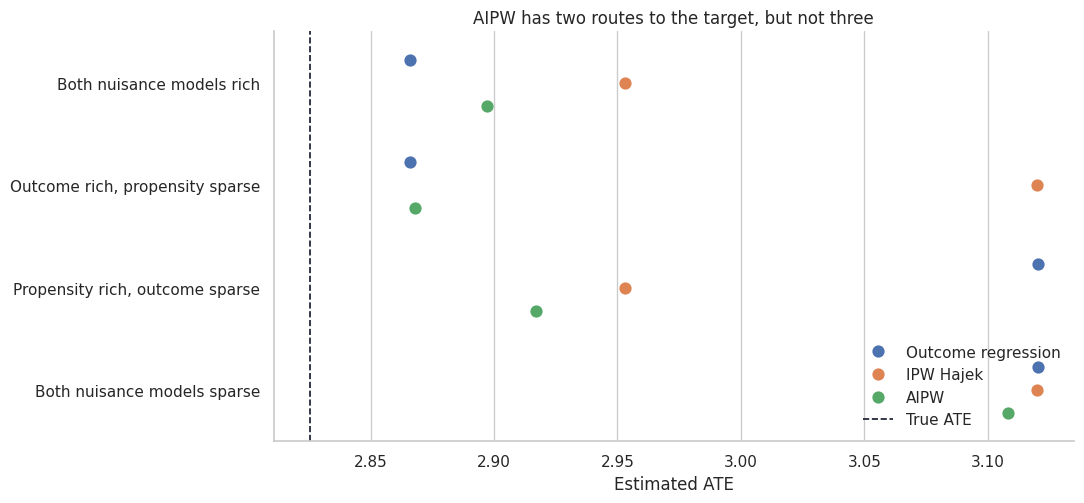

In [9]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
plot_estimates = scenario_results.melt(
    id_vars="scenario",
    value_vars=["OR_estimate", "IPW_Hajek_estimate", "AIPW_estimate"],
    var_name="estimator",
    value_name="estimate",
)
plot_estimates["estimator"] = plot_estimates["estimator"].map({
    "OR_estimate": "Outcome regression",
    "IPW_Hajek_estimate": "IPW Hajek",
    "AIPW_estimate": "AIPW",
})

fig, ax = plt.subplots(figsize=(11, 5.2))
sns.pointplot(data=plot_estimates, y="scenario", x="estimate", hue="estimator", dodge=0.45, join=False, ax=ax)
ax.axvline(true_ate, color="#0f172a", linestyle="--", linewidth=1.2, label="True ATE")
ax.set_title("AIPW has two routes to the target, but not three")
ax.set_xlabel("Estimated ATE")
ax.set_ylabel("")
ax.legend(frameon=False, loc="lower right")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

The pattern is the point.

- When the outcome model is rich, outcome regression works and AIPW is close to it even if the propensity model is sparse.
- When the propensity model is rich, IPW and AIPW have a valid route even if the outcome model is sparse.
- When both models are sparse, AIPW is not protected. Double robust means **one correct model can be enough**, not **two wrong models are fine**.

Also notice the difference between IPW Horvitz-Thompson and IPW Hajek. The Horvitz-Thompson version is closer to the textbook identifying expression, but can be noisy in finite samples. The Hajek version normalizes the treated and untreated weighted means separately and is often more stable in practice.

## 7. Decompose AIPW Into Plug-In and Residual Corrections

AIPW is easier to understand if we split the score into three pieces:

$$
\hat m_1(X_i) - \hat m_0(X_i)
$$

plus

$$
\frac{D_i\{Y_i - \hat m_1(X_i)\}}{\hat e(X_i)}
$$

minus

$$
\frac{(1-D_i)\{Y_i - \hat m_0(X_i)\}}{1-\hat e(X_i)}.
$$

The first term is the outcome-model contrast. The second and third terms correct it using weighted residuals from the actually observed outcomes.

,component,mean,std,min,max
0,plugin_contrast,3.120e+00,1.071,-0.783,6.902
1,treated_residual_correction,-2.032e-01,11.881,-231.313,139.484
2,control_residual_correction,2.704e-05,8.190,-93.951,185.145
3,aipw_score,2.917e+00,14.423,-226.394,185.632


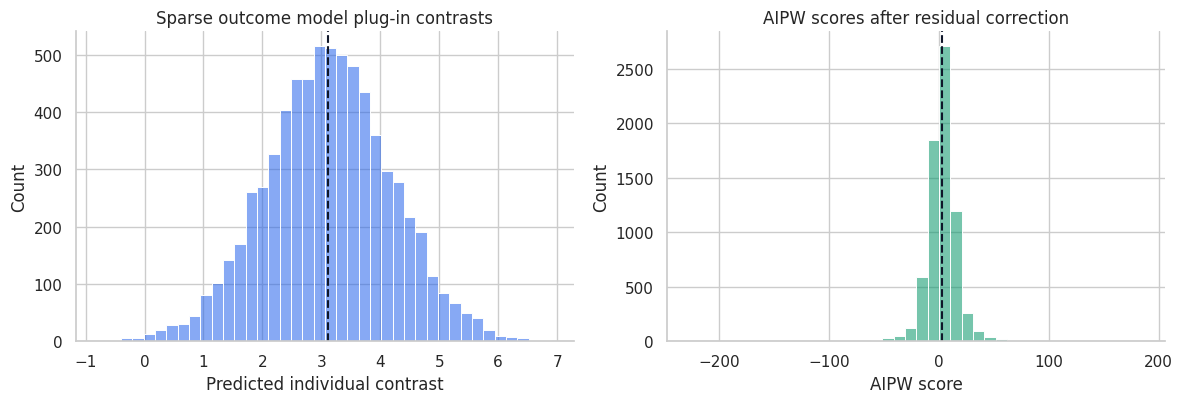

In [10]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
e_hat_good, _ = fit_propensity_formula(df, ps_formula_correct)
m0_wrong, m1_wrong, _, _ = fit_outcome_formula(df, outcome_formula_wrong)

d = df["treated"].to_numpy(dtype=float)
y = df["outcome"].to_numpy(dtype=float)
e = clip_prob(e_hat_good)

components = pd.DataFrame({
    "plugin_contrast": m1_wrong - m0_wrong,
    "treated_residual_correction": d * (y - m1_wrong) / e,
    "control_residual_correction": -(1 - d) * (y - m0_wrong) / (1 - e),
})
components["aipw_score"] = components.sum(axis=1)

component_summary = components.agg(["mean", "std", "min", "max"]).T.reset_index().rename(columns={"index": "component"})
smart_display(component_summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

sns.histplot(components["plugin_contrast"], bins=40, color="#2563eb", alpha=0.55, ax=axes[0])
axes[0].axvline(components["plugin_contrast"].mean(), color="#0f172a", linestyle="--")
axes[0].set_title("Sparse outcome model plug-in contrasts")
axes[0].set_xlabel("Predicted individual contrast")

sns.histplot(components["aipw_score"], bins=40, color="#059669", alpha=0.55, ax=axes[1])
axes[1].axvline(components["aipw_score"].mean(), color="#0f172a", linestyle="--")
axes[1].set_title("AIPW scores after residual correction")
axes[1].set_xlabel("AIPW score")

for ax in axes:
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()

Here we intentionally used a sparse outcome model with a rich propensity model. The plug-in contrast is biased because the outcome model misses important structure. The weighted residual terms correct the average because the propensity model supplies the right reweighting structure.

This is the operational meaning of double robustness: the residual correction creates a second chance, but that second chance is only trustworthy if the propensity route is credible and overlap is adequate.

## 8. AIPW Influence Values and a Simple Confidence Interval

AIPW is based on an influence-function style score. Once we compute one score per observation, the estimator is the average score:

$$
\hat \psi = \frac{1}{n}\sum_{i=1}^{n}\hat \phi_i.
$$

A simple large-sample standard error is:

$$
\widehat{SE}(\hat \psi) = \frac{sd(\hat \phi_i)}{\sqrt{n}}.
$$

This is not the final word on inference in every setting, especially with complex nuisance estimation, clustering, or repeated decisions. But it is a useful starting point for understanding how AIPW carries uncertainty.

,estimator,estimate,std_error,ci_low,ci_high,true_ate
0,AIPW with rich nuisances,2.897,0.13,2.642,3.152,2.825


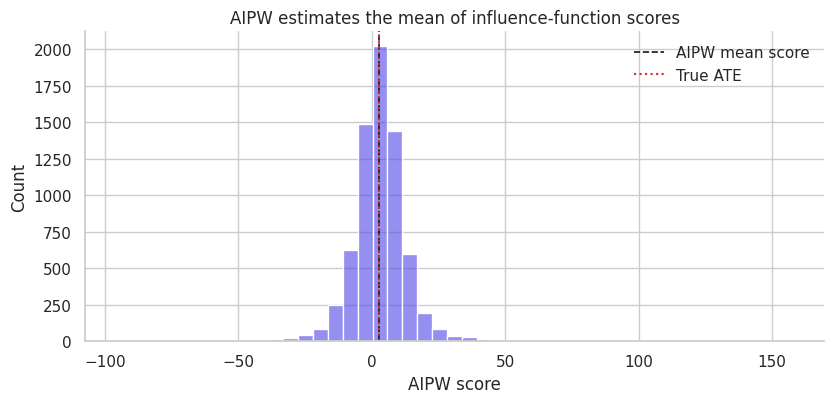

In [11]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
rich_e, _ = fit_propensity_formula(df, ps_formula_correct)
rich_m0, rich_m1, _, _ = fit_outcome_formula(df, outcome_formula_correct)
rich_aipw = aipw_estimate(df, rich_e, rich_m0, rich_m1)
rich_scores = aipw_scores(df, rich_e, rich_m0, rich_m1)

ci_table = pd.DataFrame([
    {
        "estimator": "AIPW with rich nuisances",
        "estimate": rich_aipw["estimate"],
        "std_error": rich_aipw["std_error"],
        "ci_low": rich_aipw["ci_low"],
        "ci_high": rich_aipw["ci_high"],
        "true_ate": true_ate,
    }
])

smart_display(ci_table)

fig, ax = plt.subplots(figsize=(8.5, 4.2))
sns.histplot(rich_scores, bins=45, color="#4f46e5", alpha=0.6, ax=ax)
ax.axvline(rich_aipw["estimate"], color="#0f172a", linestyle="--", linewidth=1.2, label="AIPW mean score")
ax.axvline(true_ate, color="#dc2626", linestyle=":", linewidth=1.5, label="True ATE")
ax.set_title("AIPW estimates the mean of influence-function scores")
ax.set_xlabel("AIPW score")
ax.legend(frameon=False)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

The AIPW score distribution is wider than the final standard error because the final estimator averages many scores. A few large scores can still matter. When scores have very heavy tails, the standard error increases and the estimate can become sensitive to a small number of influential observations.

## 9. Monte Carlo Check of Double Robustness

A single simulated dataset can be noisy. We will now repeat the exercise many times with smaller datasets and record bias and RMSE across repetitions.

To keep this fast, the Monte Carlo uses scikit-learn nuisance fits with hand-built feature matrices. The logic is the same as above:

- rich propensity features approximate the true assignment mechanism;
- sparse propensity features omit key variables;
- rich outcome features approximate the true outcome mechanism;
- sparse outcome features omit key variables.

In [12]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def make_feature_matrix(frame, spec):
    """Build the feature matrix object used in 07. Doubly Robust Estimation.

    Args:
        frame: Analysis DataFrame to copy, transform, summarize, or model.
        spec: Feature specification controlling which covariates are encoded.

    Returns:
        pandas.DataFrame: Encoded feature matrix for the requested nuisance-model specification.
    """
    out = pd.DataFrame(index=frame.index)
    if spec == "sparse":
        out["engagement"] = frame["engagement"]
        out["tenure"] = frame["tenure"]
    elif spec == "rich_ps":
        out["risk_score"] = frame["risk_score"]
        out["risk_score_sq"] = frame["risk_score"] ** 2
        out["engagement"] = frame["engagement"]
        out["contract_value"] = frame["contract_value"]
        out["tenure"] = frame["tenure"]
        out["support_capacity"] = frame["support_capacity"]
        dummies = pd.get_dummies(frame["segment"], prefix="segment", drop_first=True, dtype=float)
        out = pd.concat([out, dummies], axis=1)
        out["risk_x_enterprise"] = frame["risk_score"] * (frame["segment"] == "enterprise").astype(float)
    elif spec == "rich_outcome":
        out["risk_score"] = frame["risk_score"]
        out["risk_score_sq"] = frame["risk_score"] ** 2
        out["engagement"] = frame["engagement"]
        out["sin_engagement"] = np.sin(frame["engagement"] / 18)
        out["contract_value"] = frame["contract_value"]
        out["tenure"] = frame["tenure"]
        dummies = pd.get_dummies(frame["segment"], prefix="segment", drop_first=True, dtype=float)
        out = pd.concat([out, dummies], axis=1)
        out["risk_x_enterprise"] = frame["risk_score"] * (frame["segment"] == "enterprise").astype(float)
    else:
        raise ValueError(f"Unknown feature spec: {spec}")
    return out.astype(float)


def sklearn_nuisance_predictions(frame, ps_spec, outcome_spec):
    """Fit sklearn nuisance models and return propensity and outcome predictions.

    Args:
        frame: Analysis DataFrame to copy, transform, or summarize.
        ps_spec: Propensity-score model specification used in a simulation scenario.
        outcome_spec: Outcome-model specification used in a simulation scenario.

    Returns:
        tuple: Propensity and outcome predictions from sklearn nuisance models.
    """
    x_ps = make_feature_matrix(frame, ps_spec)
    x_out = make_feature_matrix(frame, outcome_spec)
    d = frame["treated"].to_numpy(dtype=int)
    y = frame["outcome"].to_numpy(dtype=float)

    ps_model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, C=1e6))
    ps_model.fit(x_ps, d)
    e_hat = clip_prob(ps_model.predict_proba(x_ps)[:, 1])

    control_model = LinearRegression()
    treated_model = LinearRegression()
    control_model.fit(x_out.loc[d == 0], y[d == 0])
    treated_model.fit(x_out.loc[d == 1], y[d == 1])
    m0_hat = control_model.predict(x_out)
    m1_hat = treated_model.predict(x_out)
    return e_hat, m0_hat, m1_hat


def run_mc_once(seed, n=1400, ps_spec="rich_ps", outcome_spec="rich_outcome"):
    """Run one Monte Carlo replication for nuisance-model estimator comparison.

    Args:
        seed: Random seed for reproducible simulation or resampling.
        n: Number of simulated units.
        ps_spec: Propensity-score model specification used in a simulation scenario.
        outcome_spec: Outcome-model specification used in a simulation scenario.

    Returns:
        pandas.DataFrame or dict: Scenario results used for comparison in the notebook.
    """
    frame = simulate_renewal_outreach(n=n, seed=seed)
    e_hat, m0_hat, m1_hat = sklearn_nuisance_predictions(frame, ps_spec, outcome_spec)
    truth = frame["true_individual_effect"].mean()
    return {
        "true_ate": truth,
        "OR": outcome_regression_estimate(m0_hat, m1_hat),
        "IPW_Hajek": ipw_hajek_estimate(frame, e_hat),
        "AIPW": aipw_estimate(frame, e_hat, m0_hat, m1_hat)["estimate"],
    }

mc_scenarios = [
    ("Both rich", "rich_ps", "rich_outcome"),
    ("Outcome rich, PS sparse", "sparse", "rich_outcome"),
    ("PS rich, outcome sparse", "rich_ps", "sparse"),
    ("Both sparse", "sparse", "sparse"),
]

mc_rows = []
for scenario_name, ps_spec, outcome_spec in mc_scenarios:
    for rep in range(80):
        row = run_mc_once(seed=9000 + 1000 * mc_scenarios.index((scenario_name, ps_spec, outcome_spec)) + rep, ps_spec=ps_spec, outcome_spec=outcome_spec)
        row["scenario"] = scenario_name
        row["rep"] = rep
        mc_rows.append(row)

mc = pd.DataFrame(mc_rows)
mc_long = mc.melt(id_vars=["scenario", "rep", "true_ate"], value_vars=["OR", "IPW_Hajek", "AIPW"], var_name="estimator", value_name="estimate")
mc_long["error"] = mc_long["estimate"] - mc_long["true_ate"]

mc_summary = (
    mc_long.groupby(["scenario", "estimator"])
    .agg(
        mean_estimate=("estimate", "mean"),
        mean_bias=("error", "mean"),
        rmse=("error", lambda x: np.sqrt(np.mean(np.asarray(x) ** 2))),
        error_sd=("error", "std"),
    )
    .reset_index()
)

smart_display(mc_summary)

,scenario,estimator,mean_estimate,mean_bias,rmse,error_sd
0,Both rich,AIPW,2.814,-7.501e-03,0.288,0.290
1,Both rich,IPW_Hajek,2.793,-2.801e-02,0.319,0.320
2,Both rich,OR,2.826,4.616e-03,0.254,0.255
3,Both sparse,AIPW,3.198,3.738e-01,0.501,0.336
4,Both sparse,IPW_Hajek,3.222,3.975e-01,0.518,0.335
5,Both sparse,OR,3.209,3.843e-01,0.512,0.340
6,"Outcome rich, PS sparse",AIPW,2.826,-2.616e-04,0.280,0.282
7,"Outcome rich, PS sparse",IPW_Hajek,3.208,3.821e-01,0.547,0.394
8,"Outcome rich, PS sparse",OR,2.828,2.066e-03,0.280,0.282
9,"PS rich, outcome sparse",AIPW,2.829,5.557e-03,0.310,0.311


In Monte Carlo Check of Double Robustness, the output is useful only if the comparison has support in the data. Weak overlap shifts the estimate toward extrapolation and away from observed comparisons.

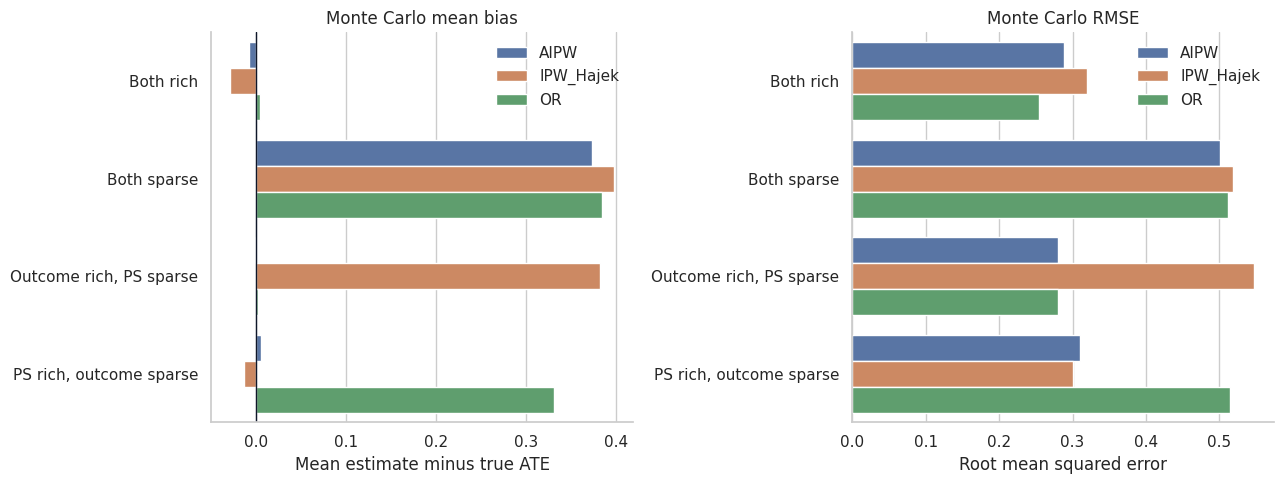

In [13]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
fig, axes = plt.subplots(1, 2, figsize=(13, 5.0))

sns.barplot(data=mc_summary, y="scenario", x="mean_bias", hue="estimator", ax=axes[0])
axes[0].axvline(0, color="#0f172a", linewidth=1)
axes[0].set_title("Monte Carlo mean bias")
axes[0].set_xlabel("Mean estimate minus true ATE")
axes[0].set_ylabel("")
axes[0].legend(frameon=False)

sns.barplot(data=mc_summary, y="scenario", x="rmse", hue="estimator", ax=axes[1])
axes[1].set_title("Monte Carlo RMSE")
axes[1].set_xlabel("Root mean squared error")
axes[1].set_ylabel("")
axes[1].legend(frameon=False)

for ax in axes:
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()

The repeated simulations show the double robust pattern more clearly than a single dataset.

- With a rich outcome model, OR and AIPW have low bias even if the propensity model is sparse.
- With a rich propensity model, IPW and AIPW have a valid route even if the outcome model is sparse.
- With both nuisance models sparse, AIPW can be biased. Sometimes it may still look reasonable, but that is not a guarantee.

Kang and Schafer (2007) are a useful antidote to overconfidence here: double robust estimators can perform poorly when both nuisance models are misspecified, especially when weights are unstable.

## 10. AIPW Still Needs Overlap

AIPW uses inverse propensity terms in the residual correction. Therefore, it inherits the need for positivity and overlap.

If $\hat e(X_i)$ is very close to zero, a treated residual can be multiplied by a very large number. If $\hat e(X_i)$ is very close to one, an untreated residual can be multiplied by a very large number.

This is why the previous notebook matters. Double robustness complements overlap diagnostics.

In [14]:
# Build the summary table used to connect the calculation back to the design question.
weak_overlap_df = simulate_renewal_outreach(n=7000, seed=7077, targeting_strength=1.85)
weak_true_ate = weak_overlap_df["true_individual_effect"].mean()

weak_e, _ = fit_propensity_formula(weak_overlap_df, ps_formula_correct)
weak_m0, weak_m1, _, _ = fit_outcome_formula(weak_overlap_df, outcome_formula_correct)
weak_weights = weak_overlap_df["treated"].to_numpy() / clip_prob(weak_e) + (1 - weak_overlap_df["treated"].to_numpy()) / (1 - clip_prob(weak_e))
weak_aipw = aipw_estimate(weak_overlap_df, weak_e, weak_m0, weak_m1)

regular_e, _ = fit_propensity_formula(df, ps_formula_correct)
regular_weights = df["treated"].to_numpy() / clip_prob(regular_e) + (1 - df["treated"].to_numpy()) / (1 - clip_prob(regular_e))
regular_m0, regular_m1, _, _ = fit_outcome_formula(df, outcome_formula_correct)
regular_aipw = aipw_estimate(df, regular_e, regular_m0, regular_m1)

positivity_table = pd.DataFrame([
    {
        "design": "Moderate targeting",
        "treated_share": df["treated"].mean(),
        "ps_p01": np.quantile(regular_e, 0.01),
        "ps_p99": np.quantile(regular_e, 0.99),
        **weight_summary(regular_weights),
        "AIPW_estimate": regular_aipw["estimate"],
        "AIPW_se": regular_aipw["std_error"],
        "true_ate": true_ate,
    },
    {
        "design": "Aggressive targeting",
        "treated_share": weak_overlap_df["treated"].mean(),
        "ps_p01": np.quantile(weak_e, 0.01),
        "ps_p99": np.quantile(weak_e, 0.99),
        **weight_summary(weak_weights),
        "AIPW_estimate": weak_aipw["estimate"],
        "AIPW_se": weak_aipw["std_error"],
        "true_ate": weak_true_ate,
    },
])

smart_display(positivity_table)

,design,treated_share,ps_p01,ps_p99,ess,ess_share_of_n,mean,sd,p95,p99,max,AIPW_estimate,AIPW_se,true_ate
0,Moderate targeting,0.355,0.052,0.824,4594.539,0.656,2.007,1.452,4.335,7.650,29.537,2.897,0.130,2.825
1,Aggressive targeting,0.412,0.012,0.977,2042.627,0.292,2.025,3.155,4.764,11.403,122.838,2.990,0.225,2.824


In AIPW Still Needs Overlap, the table shows whether the comparison is supported by nearby observed units or by extrapolation. Weak overlap narrows the population we can speak about.

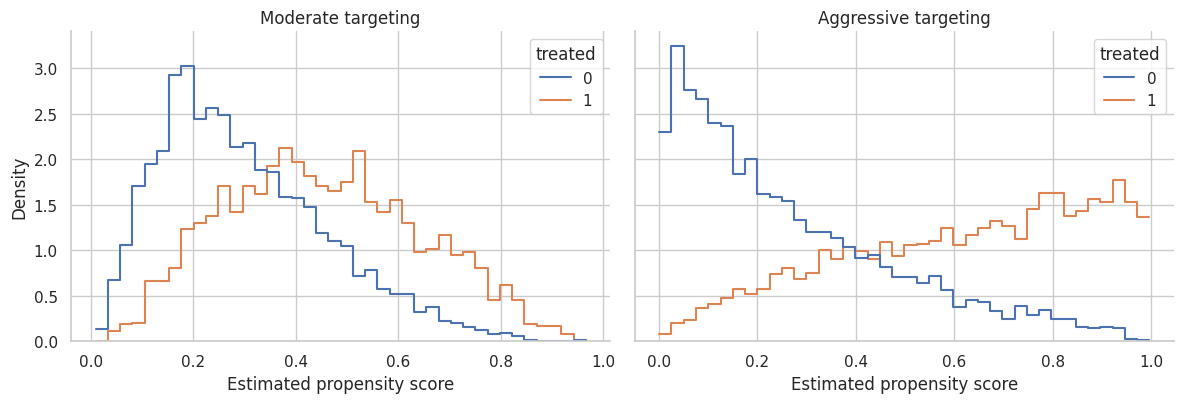

In [15]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
weak_plot = pd.concat(
    [
        pd.DataFrame({"propensity": regular_e, "treated": df["treated"], "design": "Moderate targeting"}),
        pd.DataFrame({"propensity": weak_e, "treated": weak_overlap_df["treated"], "design": "Aggressive targeting"}),
    ],
    ignore_index=True,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
for ax, design in zip(axes, ["Moderate targeting", "Aggressive targeting"]):
    sns.histplot(
        data=weak_plot.loc[weak_plot["design"] == design],
        x="propensity",
        hue="treated",
        stat="density",
        common_norm=False,
        bins=40,
        element="step",
        fill=False,
        ax=ax,
    )
    ax.set_title(design)
    ax.set_xlabel("Estimated propensity score")
    sns.despine(ax=ax)
axes[0].set_ylabel("Density")
plt.tight_layout()
plt.show()

The aggressive targeting setting creates more extreme propensity scores, larger weights, and a larger AIPW standard error. Even with rich nuisance models in this simulation, the estimate becomes less stable because fewer observations support the hard comparisons.

This is the professional warning: AIPW gives two modeling routes, but it does not give support where the data have little or none.

## 11. Cross-Fitting With Flexible Machine Learning

Modern doubly robust workflows often use flexible machine learning for the nuisance functions. That creates a new issue: if we fit very adaptive models and evaluate them on the same observations, nuisance overfitting can leak into the causal estimate.

Cross-fitting addresses this by:

1. Splitting the data into folds.
2. Training nuisance models on all folds except one.
3. Predicting nuisance values on the held-out fold.
4. Repeating until every observation has out-of-fold nuisance predictions.
5. Computing AIPW from those out-of-fold predictions.

Chernozhukov et al. (2018) develop the double/debiased machine learning framework around orthogonal scores and cross-fitting. The AIPW score we use here is one of the core examples of an orthogonal score for treatment-effect estimation.

In [16]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def ml_feature_matrix(frame):
    """Compute ml feature matrix for 07. Doubly Robust Estimation.

    Args:
        frame: Analysis DataFrame to copy, transform, summarize, or model.

    Returns:
        pandas.DataFrame: Machine-learning feature matrix with numeric and encoded categorical predictors.
    """
    x = pd.DataFrame(index=frame.index)
    x["risk_score"] = frame["risk_score"]
    x["engagement"] = frame["engagement"]
    x["contract_value"] = frame["contract_value"]
    x["tenure"] = frame["tenure"]
    x["support_capacity"] = frame["support_capacity"]
    x["risk_x_contract"] = frame["risk_score"] * frame["contract_value"]
    x["engagement_sq"] = frame["engagement"] ** 2
    dummies = pd.get_dummies(frame["segment"], prefix="segment", drop_first=True, dtype=float)
    return pd.concat([x, dummies], axis=1).astype(float)


def crossfit_aipw(frame, n_splits=5, seed=123):
    """Compute crossfit aipw for 07. Doubly Robust Estimation.

    Args:
        frame: Analysis DataFrame to copy, transform, summarize, or model.
        n_splits: Number of folds for cross-fitting.
        seed: Random seed used for reproducibility.

    Returns:
        tuple: Cross-fitted AIPW estimate, standard error, and nuisance predictions.
    """
    x = ml_feature_matrix(frame)
    d = frame["treated"].to_numpy(dtype=int)
    y = frame["outcome"].to_numpy(dtype=float)

    e_hat = np.zeros(len(frame))
    m0_hat = np.zeros(len(frame))
    m1_hat = np.zeros(len(frame))

    ps_model_template = HistGradientBoostingClassifier(max_iter=90, learning_rate=0.055, max_leaf_nodes=18, random_state=seed)
    outcome_model_template = HistGradientBoostingRegressor(max_iter=120, learning_rate=0.055, max_leaf_nodes=18, random_state=seed)

    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    for train_idx, test_idx in kfold.split(x):
        x_train, x_test = x.iloc[train_idx], x.iloc[test_idx]
        d_train = d[train_idx]
        y_train = y[train_idx]

        ps_model = clone(ps_model_template)
        ps_model.fit(x_train, d_train)
        e_hat[test_idx] = ps_model.predict_proba(x_test)[:, 1]

        m0_model = clone(outcome_model_template)
        m1_model = clone(outcome_model_template)
        m0_model.fit(x_train.loc[d_train == 0], y_train[d_train == 0])
        m1_model.fit(x_train.loc[d_train == 1], y_train[d_train == 1])
        m0_hat[test_idx] = m0_model.predict(x_test)
        m1_hat[test_idx] = m1_model.predict(x_test)

    e_hat = clip_prob(e_hat)
    return e_hat, m0_hat, m1_hat, aipw_estimate(frame, e_hat, m0_hat, m1_hat)


def same_sample_ml_aipw(frame, seed=123):
    """Estimate AIPW using same-sample machine-learning nuisance fits.

    Args:
        frame: Analysis DataFrame to copy, transform, or summarize.
        seed: Random seed for reproducible simulation or resampling.

    Returns:
        tuple: Same-sample AIPW estimate and standard error.
    """
    x = ml_feature_matrix(frame)
    d = frame["treated"].to_numpy(dtype=int)
    y = frame["outcome"].to_numpy(dtype=float)

    ps_model = HistGradientBoostingClassifier(max_iter=90, learning_rate=0.055, max_leaf_nodes=18, random_state=seed)
    m0_model = HistGradientBoostingRegressor(max_iter=120, learning_rate=0.055, max_leaf_nodes=18, random_state=seed)
    m1_model = HistGradientBoostingRegressor(max_iter=120, learning_rate=0.055, max_leaf_nodes=18, random_state=seed)

    ps_model.fit(x, d)
    m0_model.fit(x.loc[d == 0], y[d == 0])
    m1_model.fit(x.loc[d == 1], y[d == 1])

    e_hat = clip_prob(ps_model.predict_proba(x)[:, 1])
    m0_hat = m0_model.predict(x)
    m1_hat = m1_model.predict(x)
    return e_hat, m0_hat, m1_hat, aipw_estimate(frame, e_hat, m0_hat, m1_hat)

same_e, same_m0, same_m1, same_ml = same_sample_ml_aipw(df)
cf_e, cf_m0, cf_m1, cf_ml = crossfit_aipw(df)

ml_results = pd.DataFrame([
    {
        "approach": "Same-sample ML nuisances",
        "estimate": same_ml["estimate"],
        "std_error": same_ml["std_error"],
        "ci_low": same_ml["ci_low"],
        "ci_high": same_ml["ci_high"],
        "propensity_auc": roc_auc_score(df["treated"], same_e),
        "true_ate": true_ate,
    },
    {
        "approach": "Cross-fitted ML nuisances",
        "estimate": cf_ml["estimate"],
        "std_error": cf_ml["std_error"],
        "ci_low": cf_ml["ci_low"],
        "ci_high": cf_ml["ci_high"],
        "propensity_auc": roc_auc_score(df["treated"], cf_e),
        "true_ate": true_ate,
    },
])
ml_results["bias_vs_truth"] = ml_results["estimate"] - true_ate

smart_display(ml_results)

,approach,estimate,std_error,ci_low,ci_high,propensity_auc,true_ate,bias_vs_truth
0,Same-sample ML nuisances,2.867,0.102,2.668,3.066,0.798,2.825,0.042
1,Cross-fitted ML nuisances,2.910,0.133,2.650,3.170,0.722,2.825,0.085


In Cross-Fitting With Flexible Machine Learning, the output is useful only if the comparison has support in the data. When overlap is thin, the model is doing more of the work than the data.

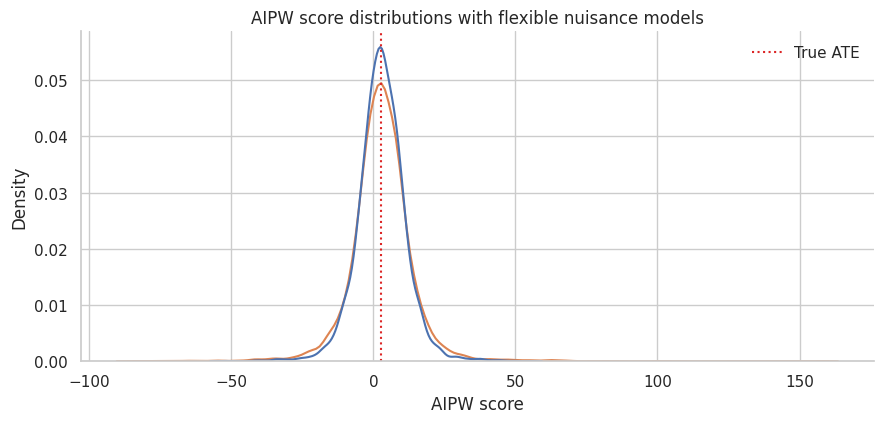

In [17]:
# Build the Cross-Fitting With Flexible Machine Learning plot from the quantities computed above.
ml_score_frame = pd.DataFrame({
    "score": np.concatenate([
        aipw_scores(df, same_e, same_m0, same_m1),
        aipw_scores(df, cf_e, cf_m0, cf_m1),
    ]),
    "approach": np.repeat(["Same-sample", "Cross-fitted"], len(df)),
})

fig, ax = plt.subplots(figsize=(9, 4.4))
sns.kdeplot(data=ml_score_frame, x="score", hue="approach", common_norm=False, fill=False, ax=ax)
ax.axvline(true_ate, color="#dc2626", linestyle=":", linewidth=1.5, label="True ATE")
ax.set_title("AIPW score distributions with flexible nuisance models")
ax.set_xlabel("AIPW score")
ax.legend(frameon=False)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

Cross-fitting is not mainly about improving prediction metrics. It is about protecting the causal score from overfitting in the nuisance models. With flexible learners, the nuisance predictions should be treated as first-stage estimates. Cross-fitting makes each observation's nuisance estimates out-of-sample.

This is one reason modern causal ML libraries build cross-fitting into doubly robust estimators. The workflow is more complex, but the principle is straightforward: use machine learning for nuisance functions without letting same-row overfitting drive the causal parameter.

## 12. Practical Diagnostics for Doubly Robust Workflows

A doubly robust analysis should still report diagnostics. A useful dashboard includes:

- propensity-score overlap;
- weight tails and effective sample size;
- covariate balance after weighting;
- outcome-model residual checks by treatment group;
- sensitivity across nuisance specifications;
- cross-fitted estimates when using flexible learners;
- a clear statement of the target estimand.

,diagnostic,value,interpretation
0,Propensity AUC,0.731,High values can signal strong targeting; inspe...
1,Maximum ATE weight,29.537,Large values indicate influential observations
2,ESS share,0.656,Lower values mean less effective information a...
3,Max weighted absolute SMD,0.018,Check whether weighting balances observed conf...
4,Mean absolute observed residual,3.594,Basic outcome-model fit check


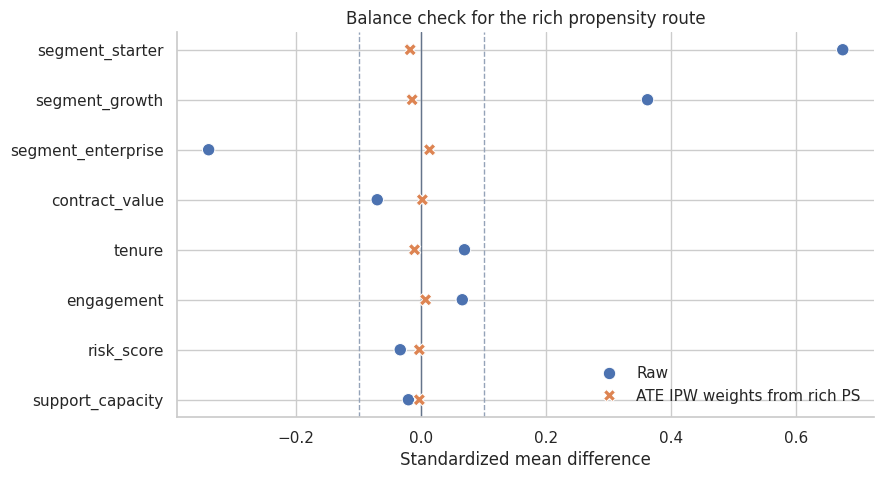

In [18]:
# Build the summary table used to connect the calculation back to the design question.
rich_weights = df["treated"].to_numpy() / clip_prob(rich_e) + (1 - df["treated"].to_numpy()) / (1 - clip_prob(rich_e))
weighted_balance = balance_table(balance_frame, balance_covariates, weights=rich_weights)

residual_frame = pd.DataFrame({
    "treated": df["treated"],
    "m_hat_observed": np.where(df["treated"].to_numpy() == 1, rich_m1, rich_m0),
    "residual": df["outcome"].to_numpy() - np.where(df["treated"].to_numpy() == 1, rich_m1, rich_m0),
    "propensity": rich_e,
    "weight": rich_weights,
})

diagnostic_dashboard = pd.DataFrame([
    {
        "diagnostic": "Propensity AUC",
        "value": roc_auc_score(df["treated"], rich_e),
        "interpretation": "High values can signal strong targeting; inspect overlap",
    },
    {
        "diagnostic": "Maximum ATE weight",
        "value": rich_weights.max(),
        "interpretation": "Large values indicate influential observations",
    },
    {
        "diagnostic": "ESS share",
        "value": effective_sample_size(rich_weights) / len(rich_weights),
        "interpretation": "Lower values mean less effective information after weighting",
    },
    {
        "diagnostic": "Max weighted absolute SMD",
        "value": weighted_balance["abs_smd"].max(),
        "interpretation": "Check whether weighting balances observed confounders",
    },
    {
        "diagnostic": "Mean absolute observed residual",
        "value": residual_frame["residual"].abs().mean(),
        "interpretation": "Basic outcome-model fit check",
    },
])

smart_display(diagnostic_dashboard)
plot_love(
    {
        "Raw": raw_balance,
        "ATE IPW weights from rich PS": weighted_balance,
    },
    title="Balance check for the rich propensity route",
    figsize=(9, 5.0),
)

This dashboard is deliberately not limited to the final estimate. Doubly robust estimators can look sophisticated enough that people skip basic diagnostics. That is backwards. The more complex the estimator, the more important it is to show the design evidence.

## 13. What to Say in an Industry Readout

A polished readout should not say:

> We used a doubly robust estimator, so the result is robust.

That is too vague and too confident.

A better readout says:

> We estimated the outreach effect using an augmented inverse probability weighted estimator. This combines an outcome model for renewal value with a propensity model for outreach assignment. The estimate is protected against misspecification of either one of these nuisance models, but not both. We therefore report diagnostics for score overlap, weight concentration, covariate balance, and sensitivity across nuisance specifications. The primary estimate targets the population represented by the observed support; extrapolation beyond that support is not recommended.

That version tells stakeholders what the estimator does, what it does not do, and why the diagnostics matter.

## 14. Common Mistakes

1. **Treating double robust as double correct**: AIPW is not guaranteed to improve on every single-robust estimator in finite samples.
2. **Ignoring overlap**: AIPW still contains inverse propensity terms.
3. **Using post-treatment variables**: both nuisance models must use pre-treatment covariates for causal interpretation.
4. **Letting prediction metrics replace design diagnostics**: high AUC or high $R^2$ still needs causal design support.
5. **Skipping sensitivity checks**: if the estimate moves sharply across nuisance specifications, the result needs a cautious interpretation.
6. **Forgetting the estimand**: AIPW for ATE, ATT, overlap-weighted targets, and longitudinal regimes are different objects.

## Key Takeaways

- AIPW combines outcome regression with inverse propensity weighted residual corrections.
- The estimator is doubly robust: it can be consistent if either the outcome model or the propensity model is correctly specified.
- Double robustness does not protect against unmeasured confounding, poor overlap, post-treatment adjustment, or both nuisance models being badly wrong.
- The AIPW score gives a useful route to uncertainty estimation through the standard deviation of observation-level scores.
- Cross-fitting helps when nuisance functions are estimated with flexible machine learning.
- In industry work, AIPW is most credible when paired with transparent overlap, balance, residual, and sensitivity diagnostics.

## References

Bang, H., & Robins, J. M. (2005). Doubly robust estimation in missing data and causal inference models. *Biometrics, 61*(4), 962-973. https://doi.org/10.1111/j.1541-0420.2005.00377.x

Chernozhukov, V., Chetverikov, D., Demirer, M., Duflo, E., Hansen, C., Newey, W., & Robins, J. (2018). Double/debiased machine learning for treatment and structural parameters. *The Econometrics Journal, 21*(1), C1-C68. https://doi.org/10.1111/ectj.12097

Funk, M. J., Westreich, D., Wiesen, C., Sturmer, T., Brookhart, M. A., & Davidian, M. (2011). Doubly robust estimation of causal effects. *American Journal of Epidemiology, 173*(7), 761-767. https://doi.org/10.1093/aje/kwq439

Kang, J. D. Y., & Schafer, J. L. (2007). Demystifying double robustness: A comparison of alternative strategies for estimating a population mean from incomplete data. *Statistical Science, 22*(4), 523-539. https://doi.org/10.1214/07-STS227

Robins, J. M., Rotnitzky, A., & Zhao, L. P. (1994). Estimation of regression coefficients when some regressors are not always observed. *Journal of the American Statistical Association, 89*(427), 846-866. https://doi.org/10.1080/01621459.1994.10476818